# Exclusive Gene Analysis: CAT vs Ensembl

This notebook rebuilds the gene-exclusive analysis directly from raw per-assembly `gene_presence` outputs in `qc_metrics/`.

It is intended for the HPC results directory, where the current aggregate artifacts are incomplete or misleading for CAT-only vs Ensembl-only interpretation.

Questions this notebook targets:
- Is CAT's higher gene count coming from canonical GRCh38-like genes or mostly extra CAT-added models?
- What fraction of CAT-only genes are `MSTRG`, clone-style loci, `CHM13_G` IDs, or standard symbols?
- For CAT-only genes, how much comes from CAT source models versus Liftoff?
- Which protein-coding catalog-like genes are repeatedly CAT-only or Ensembl-only across assemblies?

In [10]:
import pandas as pd
from exclusive_gene_analysis_lib import CATALOG_NAME_CLASSES, make_overview_figure, run_analysis

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

results = run_analysis()
paths = results['paths']
files = results['files']

print('OUTPUT_DIR:', paths['output_dir'])
print('QC_DIR:', paths['qc_dir'])
print('CAT_CACHE_DIR:', paths['cat_cache_dir'])

print('gene_presence files:', len(files['gene_presence_files']))
print('Ensembl gene count files:', len(files['ensembl_gene_count_files']))
print('CAT gene count files:', len(files['cat_gene_count_files']))
print('analysis output:', paths['analysis_dir'])

OUTPUT_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results
QC_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics
CAT_CACHE_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/cache/cat
gene_presence files: 462
Ensembl gene count files: 462
CAT gene count files: 462
analysis output: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/intermediate_spreadsheets/exclusive_gene_analysis


In [11]:
assembly = results['assembly_overview']
exclusive_obs = results['exclusive_obs']
exclusive_rollup = results['exclusive_rollup']
cat_only = results['cat_only_enriched']

summary = pd.DataFrame([
    {
        'median CAT - Ensembl total genes': assembly['delta_total'].median(),
        'median CAT - Ensembl non-fallback genes': assembly['delta_non_fallback'].median(),
        'median CAT - Ensembl catalog-like genes': assembly['delta_catalog_like'].median(),
        'median CAT - Ensembl protein_coding genes': assembly['delta_protein_coding'].median(),
        'median CAT - Ensembl protein_coding catalog-like genes': assembly['delta_protein_coding_catalog_like'].median(),
        'CAT-only exclusive observations': int((exclusive_obs['exclusive_side'] == 'cat_only').sum()),
        'Ensembl-only exclusive observations': int((exclusive_obs['exclusive_side'] == 'ensembl_only').sum()),
        'CAT-only exclusive genes': int((exclusive_rollup['n_assemblies_cat_only'] > 0).sum()),
        'Ensembl-only exclusive genes': int((exclusive_rollup['n_assemblies_ensembl_only'] > 0).sum()),
    }
])
display(summary.T.rename(columns={0: 'value'}))

display(results['exclusive_name_summary'])
display(results['exclusive_biotype_summary'].head(30))
display(results['cat_only_source_summary'].head(30))

,value
median CAT - Ensembl total genes,3235.5
median CAT - Ensembl non-fallback genes,1404.5
median CAT - Ensembl catalog-like genes,1410.0
median CAT - Ensembl protein_coding genes,589.5
median CAT - Ensembl protein_coding catalog-like genes,127.0
CAT-only exclusive observations,16819657.0
Ensembl-only exclusive observations,17006225.0
CAT-only exclusive genes,233404.0
Ensembl-only exclusive genes,16927805.0


,exclusive_side,name_class,n_observations
0,cat_only,ENSG_fallback,16408212
1,cat_only,standard_symbol,301688
2,cat_only,hyphenated_symbol,107668
3,cat_only,orf_symbol,1397
4,cat_only,clone_locus,692
5,ensembl_only,ENSG_fallback,16933949
6,ensembl_only,standard_symbol,60245
7,ensembl_only,hyphenated_symbol,7212
8,ensembl_only,clone_locus,2969
9,ensembl_only,orf_symbol,1850


,exclusive_side,exclusive_biotype,n_observations
0,cat_only,lncRNA,13306997
1,cat_only,processed_pseudogene,1400684
2,cat_only,TEC,459096
3,cat_only,protein_coding,383535
4,cat_only,unprocessed_pseudogene,342677
5,cat_only,transcribed_unprocessed_pseudogene,205184
6,cat_only,unknown_likely_coding,191969
7,cat_only,transcribed_processed_pseudogene,183269
8,cat_only,snoRNA,152299
9,cat_only,misc_RNA,111029


,cat_source,name_class,cat_biotype,n_observations
0,CAT,ENSG_fallback,lncRNA,13261867
1,CAT,ENSG_fallback,processed_pseudogene,1384724
2,CAT,ENSG_fallback,TEC,459093
3,CAT,ENSG_fallback,unprocessed_pseudogene,329920
4,CAT,ENSG_fallback,protein_coding,283065
5,CAT,ENSG_fallback,transcribed_unprocessed_pseudogene,192328
6,CAT,standard_symbol,unknown_likely_coding,191969
7,CAT,ENSG_fallback,transcribed_processed_pseudogene,179220
8,CAT,ENSG_fallback,snoRNA,151883
9,CAT,ENSG_fallback,misc_RNA,109238


In [12]:
cat_pc_catalog = (
    cat_only[
        cat_only['cat_biotype'].eq('protein_coding')
        & cat_only['catalog_like']
    ]
    .groupby(['gene_name', 'cat_source'], dropna=False)
    .size()
    .reset_index(name='n_assemblies_cat_only')
    .sort_values(['n_assemblies_cat_only', 'gene_name'], ascending=[False, True])
)

ens_pc_catalog = (
    exclusive_rollup[
        exclusive_rollup['ensembl_biotype'].eq('protein_coding')
        & exclusive_rollup['catalog_like']
        & (exclusive_rollup['n_assemblies_ensembl_only'] > 0)
    ][['gene_name', 'n_assemblies_ensembl_only', 'ensembl_chrom']]
    .sort_values(['n_assemblies_ensembl_only', 'gene_name'], ascending=[False, True])
)

display(cat_pc_catalog.head(50))
display(ens_pc_catalog.head(50))

cat_name_breakdown = (
    cat_only[
        cat_only['cat_biotype'].eq('protein_coding')
        & (cat_only['cat_source'] == 'CAT')
    ]
    .groupby('name_class', dropna=False)
    .size()
    .reset_index(name='n_observations')
    .sort_values('n_observations', ascending=False)
)
display(cat_name_breakdown)

,gene_name,cat_source,n_assemblies_cat_only
2,ABCF2-H2BK1,CAT,462
3,ABHD14A-ACY1,CAT,462
30,ANKHD1-EIF4EBP3,CAT,462
42,APOC4-APOC2,CAT,462
45,ARHGAP11A-SCG5,CAT,462
47,ARHGAP19-SLIT1,CAT,462
56,ARL2-SNX15,CAT,462
57,ARPC4-TTLL3,CAT,462
67,ATF7-NPFF,CAT,462
69,ATP5MF-PTCD1,CAT,462


,gene_name,n_assemblies_ensembl_only,ensembl_chrom
35,ADAL,462,JAGYVI020000045.1
240,BMT2,462,CM089261.1
275,C2orf50,462,CM089257.1
276,C2orf73,462,CM089257.1
282,C5orf60,462,CM089259.1
277,C3orf84,461,JAGYVI020000044.1
502,CSNKA2IP,461,JAGYVI020000044.1
17159585,TRAPPC10,457,JAGYVI020000006.1
17117502,MAFIP,441,JAGYVI020000002.1
316,CCNYL1B,425,JAGYVI020000047.1


,name_class,n_observations
0,ENSG_fallback,283065
2,hyphenated_symbol,64515
4,standard_symbol,34790
1,clone_locus,692
3,orf_symbol,473


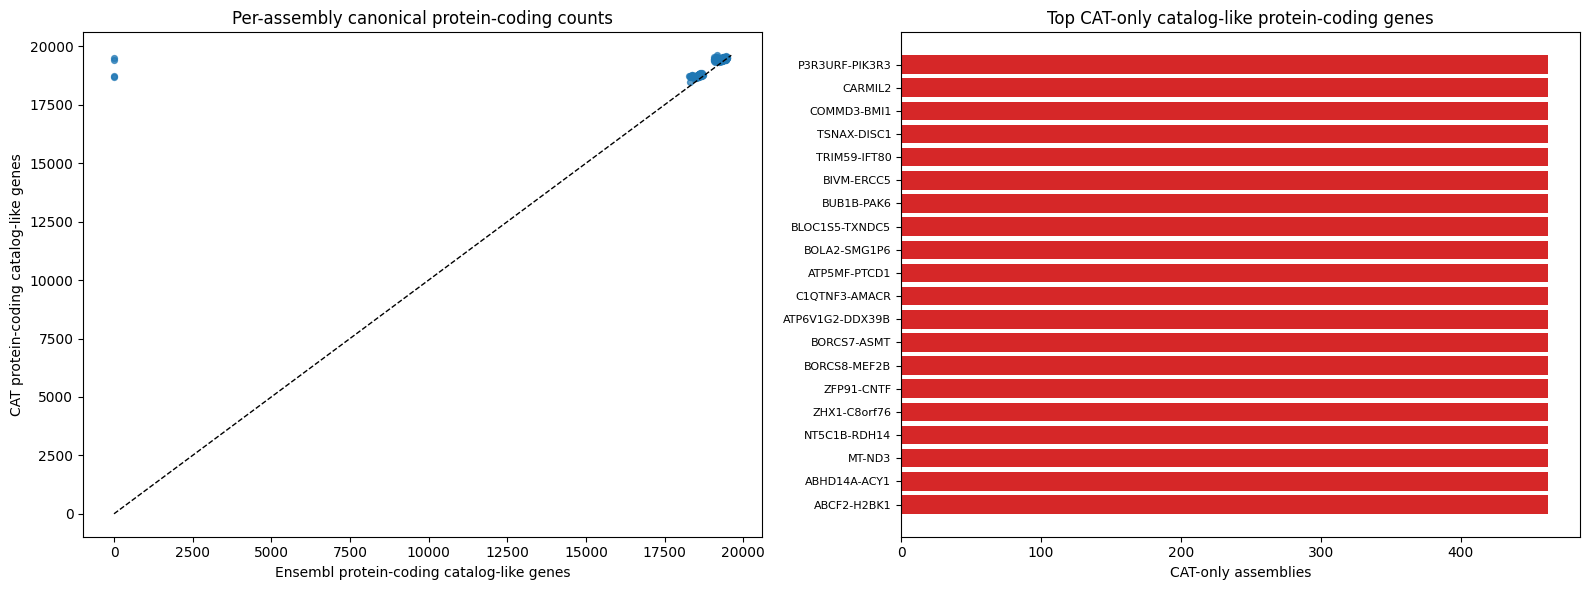

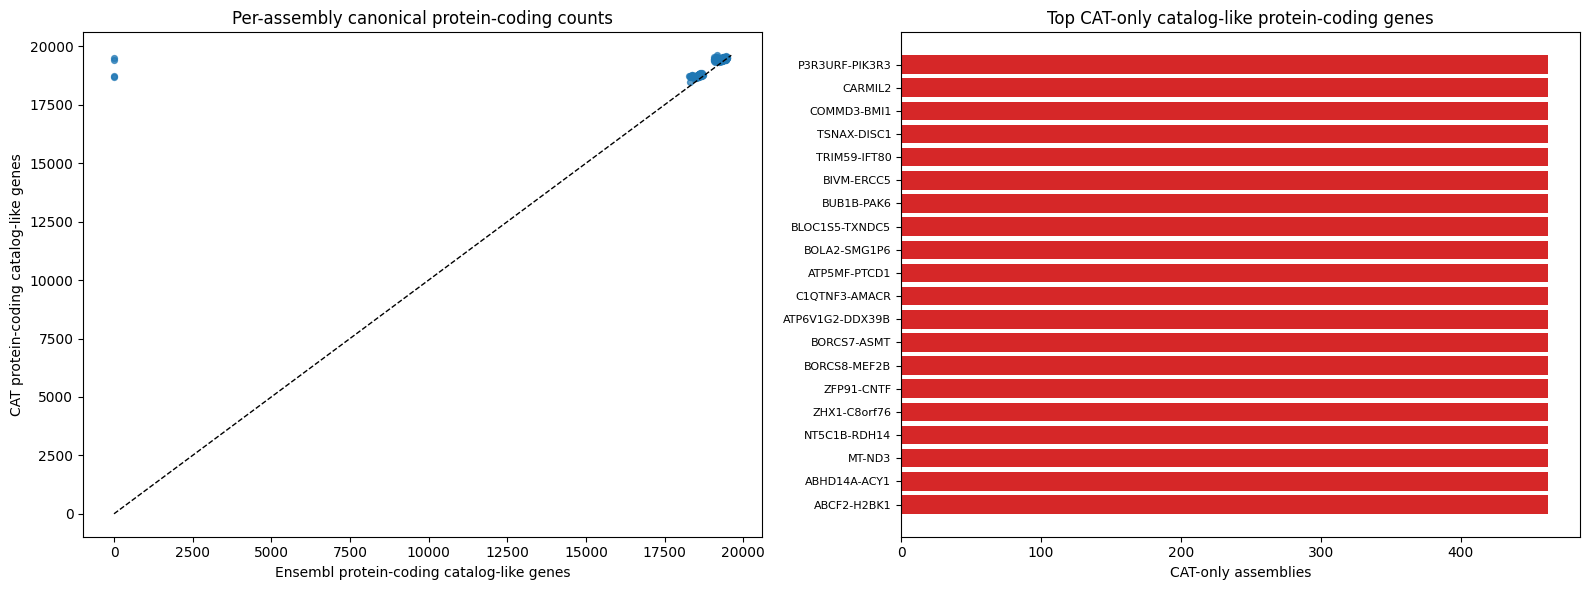

In [13]:
fig, axes = make_overview_figure(results, top_n=20)
fig

---
## Follow-up Investigations

Four lines of enquiry into both the "explained" and unexplained exclusive-gene differences:

1. **Readthrough genes** — do CAT readthrough models (e.g. `ABCF2-H2BK1`) appear in
   `gene_pairs_all` overlapping the two Ensembl component genes, and are they classified
   as `Merge` in the multi-mapping module?
2. **`unknown_likely_coding`** — do these Kinnex-supported CAT-only genes overlap any
   Ensembl model in `gene_pairs_all`, or are they in truly unannotated regions?
3. **Ensembl-only patch/alt genes** — are the consistently Ensembl-only catalog-like genes
   (e.g. `ADAL`, `BMT2`) on GRCh38 primary chromosomes or alt/patch sequences?
4. **Residual catalog-like exclusives** — for the unexplained catalog-like exclusives on
   both sides, does `gene_pairs_all` show a spatial overlap that failed the 0.95 RBH
   coverage threshold, or are these genes entirely absent from CAT/Ensembl?

> **Note:** cells 3 and 4 require HPC result files (`gene_pairs_all`, `multi_mapping`).
> If those files are not present the DataFrames will be empty and clearly flagged.

In [ ]:
from exclusive_gene_analysis_lib import run_followup_investigations

followup = run_followup_investigations(results)

pairs_all   = followup['pairs_all']
mm          = followup['multi_mapping']

print(f"gene_pairs_all rows loaded : {len(pairs_all):,}")
print(f"multi_mapping rows loaded  : {len(mm):,}")
if pairs_all.empty:
    print("\nWARNING: gene_pairs_all is empty — HPC results/ files not present.")
    print("Investigations 1, 2, and 4 will show empty DataFrames.")
if mm.empty:
    print("\nWARNING: multi_mapping is empty — HPC qc_metrics files not present.")
    print("Investigation 1 (multi-mapping classification) will be empty.")

### Investigation 1 — Readthrough genes

**Question A:** Do the CAT readthrough models also appear in `gene_pairs_all` overlapping
Ensembl component genes — i.e. does one CAT gene cover parts of two separate Ensembl genes?

**Question B:** Are they classified as `Merge` (one CAT spans multiple Ensembl) by the
multi-mapping module, confirming they cause no 1-to-1 matching confusion?

In [ ]:
rt_in_pairs = followup['readthrough_in_pairs']
rt_multi    = followup['readthrough_multi']

# ── A: readthrough CAT genes found in gene_pairs_all ─────────────────────────
if rt_in_pairs.empty:
    print("No readthrough genes found in gene_pairs_all (data unavailable or no overlaps).")
else:
    # How many unique readthrough CAT gene IDs appear in gene_pairs_all?
    n_rt_ids = rt_in_pairs['cat_gene_id'].nunique()
    # How many distinct Ensembl genes do they overlap?
    n_ens_overlapped = rt_in_pairs['ensembl_gene_id'].nunique() if 'ensembl_gene_id' in rt_in_pairs.columns else None
    print(f"Readthrough CAT gene IDs found in gene_pairs_all : {n_rt_ids:,}")
    print(f"Distinct Ensembl genes they overlap              : {n_ens_overlapped:,}")
    print()
    # Per readthrough: how many Ensembl partners does it overlap?
    partners_per_rt = (
        rt_in_pairs.groupby('cat_gene_id')['ensembl_gene_id']
        .nunique()
        .value_counts()
        .rename_axis('n_ensembl_partners')
        .reset_index(name='n_readthrough_genes')
    )
    print("Ensembl partners per readthrough CAT gene:")
    display(partners_per_rt)

    # Coverage fractions — are readthroughs partially covering each component?
    print("\nMean coverage fractions for readthrough overlaps:")
    display(
        rt_in_pairs[['frac_ensembl_covered', 'frac_cat_covered']]
        .describe()
        .loc[['mean', '50%', 'min', 'max']]
        .rename(index={'50%': 'median'})
    )

# ── B: multi-mapping classification of readthrough CAT genes ─────────────────
if rt_multi.empty:
    print("\nNo multi-mapping rows for readthrough genes (data unavailable or no multi-maps).")
else:
    print("\nMulti-mapping classifications for readthrough CAT genes:")
    display(
        rt_multi.groupby('classification')
        .agg(n_gene_assemblies=('gene_id', 'count'), n_unique_genes=('gene_id', 'nunique'))
        .reset_index()
        .sort_values('n_gene_assemblies', ascending=False)
    )

### Investigation 2 — `unknown_likely_coding` genes (Kinnex-supported)

**Question:** Do these CAT-only genes overlap any Ensembl model in `gene_pairs_all`
(i.e. are they in regions Ensembl also annotated, just with a different biotype)?
Or are they in regions Ensembl left entirely unannotated?

In [ ]:
ulc_in_pairs = followup['ulc_in_pairs']
cat_only     = results['cat_only_enriched']

ulc_obs = cat_only[cat_only['cat_biotype'].eq('unknown_likely_coding')]
n_ulc_unique_genes = ulc_obs['gene_name'].nunique()
n_ulc_unique_ids   = ulc_obs['cat_gene_id'].dropna().nunique()
print(f"unknown_likely_coding CAT-only observations : {len(ulc_obs):,}")
print(f"  unique gene names                         : {n_ulc_unique_genes:,}")
print(f"  unique CAT gene IDs                       : {n_ulc_unique_ids:,}")

if ulc_in_pairs.empty:
    print("\nNo unknown_likely_coding genes found in gene_pairs_all (data unavailable).")
else:
    n_ulc_in_pairs = ulc_in_pairs['cat_gene_id'].nunique()
    pct = 100 * n_ulc_in_pairs / max(n_ulc_unique_ids, 1)
    print(f"\nunknown_likely_coding IDs with ANY Ensembl overlap in gene_pairs_all: "
          f"{n_ulc_in_pairs:,} / {n_ulc_unique_ids:,} ({pct:.1f}%)")
    print("  → remainder are in regions Ensembl left entirely unannotated")

    # What Ensembl biotypes do they overlap when there IS an overlap?
    if 'ensembl_biotype' in ulc_in_pairs.columns:
        print("\nEnsembl biotypes overlapped by unknown_likely_coding genes:")
        display(
            ulc_in_pairs.groupby('ensembl_biotype', dropna=False)
            .agg(
                n_pairs=('cat_gene_id', 'count'),
                n_unique_cat_ids=('cat_gene_id', 'nunique'),
                median_frac_cat_covered=('frac_cat_covered', 'median'),
            )
            .reset_index()
            .sort_values('n_pairs', ascending=False)
        )

    # Coverage fractions for overlapping pairs
    if 'frac_ensembl_covered' in ulc_in_pairs.columns:
        print("\nCoverage fractions (unknown_likely_coding overlaps with Ensembl):")
        display(
            ulc_in_pairs[['frac_ensembl_covered', 'frac_cat_covered']]
            .describe()
            .loc[['mean', '50%', 'min', 'max']]
            .rename(index={'50%': 'median'})
        )

### Investigation 3 — Ensembl-only exclusive genes: primary assembly or alt/patch?

Genes such as `ADAL`, `BMT2`, `C2orf50` appear as Ensembl-only in every assembly
and are absent from `gene_positions_grch38.parquet` (GENCODE v47 primary assembly).
This cell queries the Ensembl REST API to find their GRCh38 `seq_region` and determine
whether they sit on a primary chromosome or an alt locus / patch sequence.

In [ ]:
ens_only_grch38 = followup['ens_only_grch38']

if ens_only_grch38.empty or 'grch38_seq_region' not in ens_only_grch38.columns:
    print("GRCh38 location data unavailable (REST lookup returned nothing or no Ensembl-only exclusives).")
else:
    print(f"Top Ensembl-only catalog-like exclusives with GRCh38 location data: {len(ens_only_grch38)}")

    # Split into primary vs alt/patch
    primary = ens_only_grch38[ens_only_grch38['is_primary_assembly'].eq(True)]
    alt     = ens_only_grch38[ens_only_grch38['is_primary_assembly'].eq(False)]
    missing = ens_only_grch38[ens_only_grch38['grch38_seq_region'].isna()]

    print(f"\n  On GRCh38 primary chromosomes : {len(primary)}")
    print(f"  On GRCh38 alt/patch sequences : {len(alt)}")
    print(f"  Not found in Ensembl GRCh38   : {len(missing)}")

    if not alt.empty:
        print("\nAlt/patch genes (Ensembl-only exclusives on non-primary GRCh38 sequences):")
        display(
            alt[['gene_name', 'n_assemblies', 'ensembl_chrom', 'grch38_seq_region', 'grch38_assembly_name']]
            .sort_values('n_assemblies', ascending=False)
            .head(40)
        )

    if not primary.empty:
        print("\nPrimary-chromosome genes that are still Ensembl-only (unexpected — investigate further):")
        display(
            primary[['gene_name', 'n_assemblies', 'ensembl_chrom', 'grch38_seq_region']]
            .sort_values('n_assemblies', ascending=False)
            .head(40)
        )

    if not missing.empty:
        print("\nGenes absent from Ensembl GRCh38 entirely (novel HPRC-only or very recent annotations):")
        display(
            missing[['gene_name', 'n_assemblies', 'ensembl_chrom']]
            .sort_values('n_assemblies', ascending=False)
            .head(20)
        )

### Investigation 4 — Residual catalog-like exclusives: coverage-threshold rejects vs truly absent

For the catalog-like exclusive genes that are NOT explained by readthroughs, Kinnex
`unknown_likely_coding`, or patch/alt-region gaps, classify each gene as:

- **`in_pairs_all_non_rbh`** — appears in `gene_pairs_all` with a spatial overlap but
  did not become an RBH pair (low coverage fraction, biotype mismatch, or outcompeted
  by a better match). These are coverage-threshold rejects, not truly absent.
- **`rbh_only`** — present in `gene_pairs_all` via name-match only (no spatial overlap).
- **`absent`** — no entry in `gene_pairs_all` at all; the annotation simply does not
  exist in the other toolkit.

In [ ]:
residual_cat = followup['residual_cat_only']
residual_ens = followup['residual_ens_only']

def _pairs_status_summary(df: pd.DataFrame, side: str) -> None:
    if df.empty:
        print(f"{side}: no residual catalog-like exclusives.")
        return
    if 'pairs_status' not in df.columns:
        print(f"{side}: pairs_status column missing — gene_pairs_all unavailable.")
        return

    status_counts = (
        df.groupby('pairs_status')
        .agg(n_observations=('gene_name', 'count'), n_unique_genes=('gene_name', 'nunique'))
        .reset_index()
        .sort_values('n_observations', ascending=False)
    )
    total_obs  = len(df)
    total_genes = df['gene_name'].nunique()
    print(f"{side}: {total_obs:,} observations, {total_genes:,} unique gene names")
    display(status_counts)

    # For those with overlaps (non_rbh), what are the coverage fractions?
    if 'pairs_data_unavailable' not in df['pairs_status'].values:
        in_pairs = df[df['pairs_status'].eq('in_pairs_all_non_rbh')]
        if not in_pairs.empty:
            print(f"\n  Genes with spatial overlap but not RBH ({side}):")
            display(
                in_pairs.groupby('gene_name')
                .agg(
                    n_assemblies=('assembly_accession', 'nunique'),
                    cat_biotype=('cat_biotype', 'first'),
                    ensembl_biotype=('ensembl_biotype', 'first'),
                )
                .reset_index()
                .sort_values('n_assemblies', ascending=False)
                .head(30)
            )

print("── CAT-only residual ─────────────────────────────────────────────────────")
_pairs_status_summary(residual_cat, "CAT-only")

print("\n── Ensembl-only residual ──────────────────────────────────────────────────")
_pairs_status_summary(residual_ens, "Ensembl-only")